Youtube View Predictor

Mae 2358.76
Mse 8386680.75
rMse 2895.98
r2 0.99


Enter likes:  1
Enter dislikes:  2
Enter comments:  3
Enter subscribers:  4
Enter category encoded value:  music


Predicted Views: 6009.897100958202


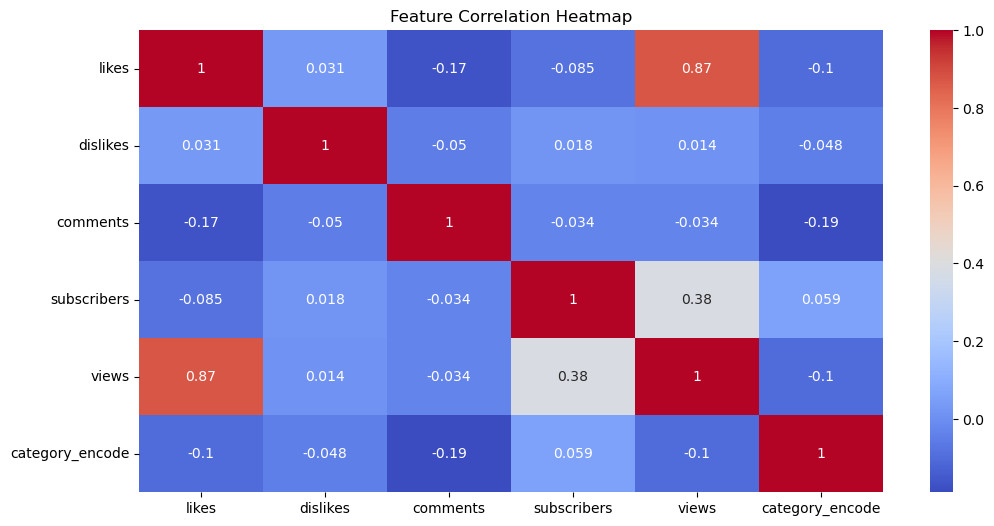

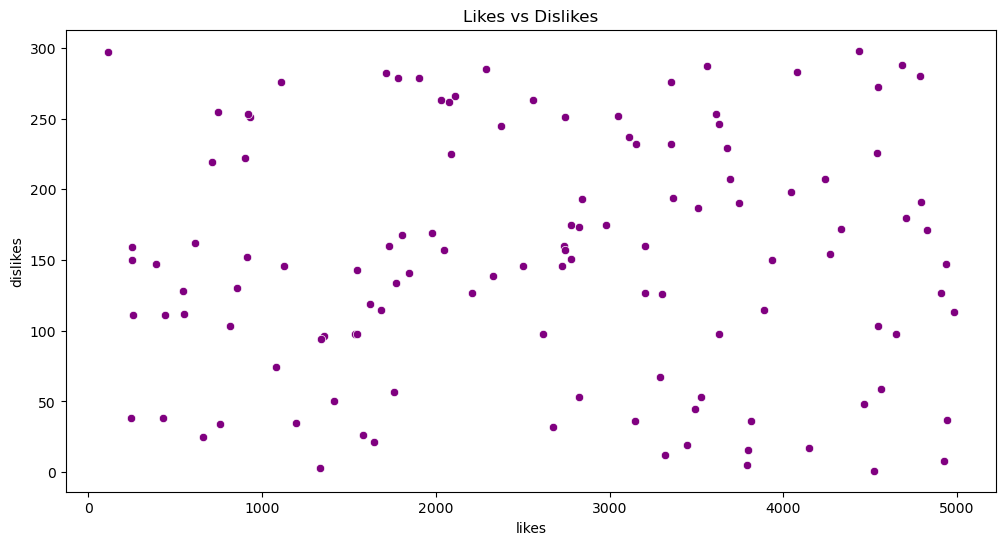

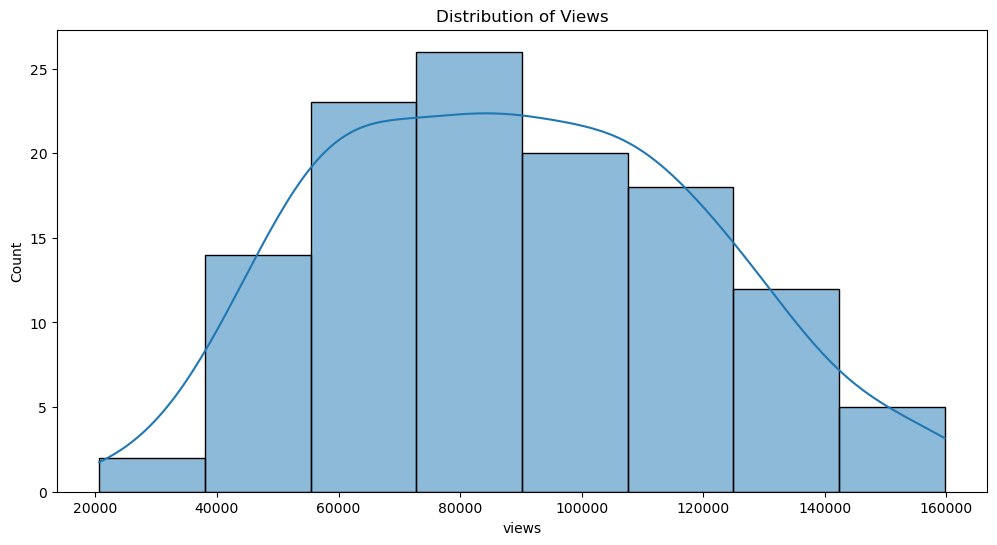

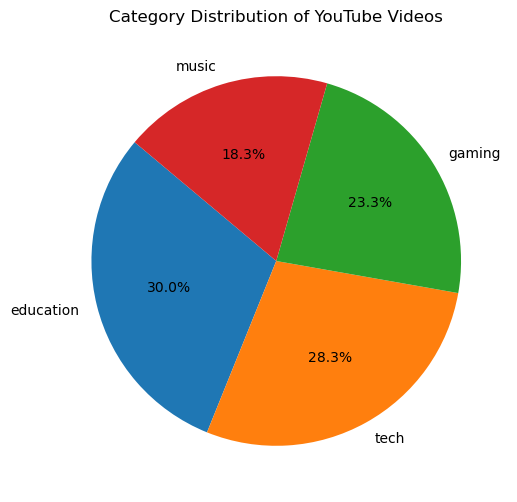

In [73]:
import numpy as np 
import pandas as pd 
import json
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_absolute_error,mean_squared_error,r2_score

data= pd.read_csv("youtube_dataset.csv")

df = data.copy() 
df.head()


le = LabelEncoder()
df['category_encode'] = le.fit_transform(df['category'])
df


X = df[["likes", "dislikes", "comments", "subscribers", "category_encode"]]
y = df["views"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train,Y_train)

y_predict= model.predict(X_test)

mae = mean_absolute_error(Y_test,y_predict)
mse = mean_squared_error(Y_test,y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,y_predict)

print("Mae",round(mae,2))
print("Mse",round(mse,2))
print("rMse",round(rmse,2))
print("r2",round(r2,2))


# user prediction
likes = float(input("Enter likes: "))
dislikes = float(input("Enter dislikes: "))
comments = float(input("Enter comments: "))
subscribers = float(input("Enter subscribers: "))
category = input("Enter category encoded value: ")


# convert category to number
if category in le.classes_:
    category_encoded = le.transform([category])[0]
else:
    print("Unknown category! using default 0")
    category_encoded = 0

new_input = pd.DataFrame([[likes, dislikes, comments, subscribers, category_encoded]],
                         columns=["likes", "dislikes", "comments", "subscribers", "category_encode"])

new_input_scaled =scaler.transform(new_input)
new_prediction = model.predict(new_input_scaled)
print("Predicted Views:", new_prediction[0])

fig = plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

fig = plt.figure(figsize=(12,6))
sns.scatterplot(x='likes',y='dislikes',data=df,color="purple")
plt.title("Likes vs Dislikes")
plt.show()

fig = plt.figure(figsize=(12,6))
sns.histplot(df['views'],kde=True)
plt.title("Distribution of Views")
plt.show()

category_counts = df['category'].value_counts()

plt.figure(figsize=(12,6))
plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Category Distribution of YouTube Videos")
plt.show()